# 1. Import

In [ ]:
# --- plot_revision setup ---
import sys
from pathlib import Path
# this notebook lives in plot_revision/scripts/, so plot_revision/ is its parent
_HERE = Path.cwd().resolve()
# tolerate cwd being either plot_revision/scripts or plot_revision or the repo root
for cand in (_HERE.parent, _HERE / "plot_revision", _HERE):
    if (cand / "paths.py").exists():
        sys.path.insert(0, str(cand))
        break
from paths import (
    REPO, ensure_out_dir,
    RESULT_DIR, RESULT_HUMAN_DIR, RESULT_MOUSE_DIR, RESULT_MULTI_DIR,
    SPC_MULTI_CSV, CLAUDE_CLADE_DIR, TREE_NWK,
)
OUT_DIR = ensure_out_dir()
# Make `dataset.*` / `config` importable inside notebook cells
from paths import add_repo_to_syspath
add_repo_to_syspath()


In [9]:

# This source code is licensed under the license found in the
# LICENSE file in the root directory of this source tree.
# --------------------------------------------------------
# References:
# Sagittarius to https://github.com/addiewc/Sagittarius
# --------------------------------------------------------
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import seaborn as sns
from plot_settings import colors as candidate_colors
from plot_utils import plot_box_with_points

import matplotlib.gridspec as gridspec

plt.style.use('seaborn-v0_8-white')


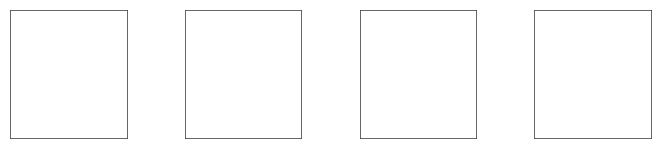

In [10]:
fig = plt.figure(figsize=(8.27, 2.5))

# 定义 GridSpec
# 前两行 4 列，第三行 1 列
gs = gridspec.GridSpec(
    3, 4,
    figure=fig,
    height_ratios=[0.5, 2, 0.5],  # 可以调整最后一行更高一些
    hspace=0, wspace=0.5
)

# 前两行各4个子图
axes_top = []
for i in [1]:  # 行
    row_axes = []
    for j in range(4):  # 列
        ax = fig.add_subplot(gs[i, j])
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)
        row_axes.append(ax)
    axes_top.append(row_axes)



In [11]:
import matplotlib as mpl
plt.rcParams.update({'font.size': 8})
print("xtick.labelsize:", mpl.rcParams['xtick.labelsize'])
print("ytick.labelsize:", mpl.rcParams['ytick.labelsize'])
print("axes.labelsize:", mpl.rcParams['axes.labelsize'])
print("axes.titlesize:", mpl.rcParams['axes.titlesize'])
print("legend.fontsize:", mpl.rcParams['legend.fontsize'])


xtick.labelsize: medium
ytick.labelsize: medium
axes.labelsize: medium
axes.titlesize: large
legend.fontsize: medium


In [12]:
color_maps = {
    'Evo2HiC' : candidate_colors[0],
    'HiCARN2' : candidate_colors[1],
    'HiCARN1' : candidate_colors[2],
    'HiCNN' : candidate_colors[3]
}

# 3. Mouse

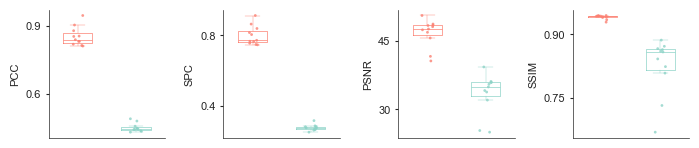

In [13]:


methods = ['Evo2HiC', 'HiCNN']

# Metric: MSE
colors = [color_maps[n] for n in methods]
NUM=len(methods)

results = pd.read_csv((RESULT_MOUSE_DIR / 'PCC.csv'), sep='\t')

plot_box_with_points(axes_top[0][0], results, methods, colors=colors, ylabel='PCC', point_size=2, sig_pair = ('Evo2HiC', 'HiCARN2'), yticks_num=2)

results = pd.read_csv((RESULT_MOUSE_DIR / 'SPC.csv'), sep='\t')

plot_box_with_points(axes_top[0][1], results, methods, colors=colors, ylabel='SPC',point_size=2, sig_pair = ('Evo2HiC', 'HiCARN2'), yticks_num=2)

results = pd.read_csv((RESULT_MOUSE_DIR / 'PSNR.csv'), sep='\t')

plot_box_with_points(axes_top[0][2], results, methods, colors=colors, ylabel='PSNR',point_size=2, sig_pair = ('Evo2HiC', 'HiCARN2'), yticks_num=2)

results = pd.read_csv((RESULT_MOUSE_DIR / 'SSIM.csv'), sep='\t')

plot_box_with_points(axes_top[0][3], results, methods, colors=colors, ylabel='SSIM',point_size=2, sig_pair = ('Evo2HiC', 'HiCARN2'), yticks_num=2)

# row = 0  # 想加标题的行
# axs_row = axes_top[row]  # 这一行的所有子图

# # 计算该行最左和最右子图的位置
# bbox_left = axs_row[0].get_position()
# bbox_right = axs_row[-1].get_position()

# # 计算该行的水平中心和顶部位置
# center_x = (bbox_left.x0 + bbox_right.x1) / 2
# top_y = max(ax.get_position().y1 for ax in axs_row)

# # 在这一行上方加一个“局部 suptitle”
# fig.text(center_x, top_y + 0.01, "Mouse", ha='center', va='bottom',
#          fontsize=12)
fig

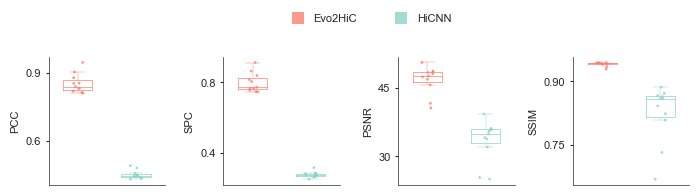

In [14]:
pos0, pos1 = axes_top[0][0].get_position(), axes_top[0][3].get_position()
x = (pos0.x0+pos1.x1)/2
y = pos0.y1 + 0.15

labels = ['Evo2HiC', 'HiCNN']

# 删除旧 legend（防止重复）
if hasattr(fig, "legend_") and fig.legend_ is not None:
    fig.legend_.remove()

handles = [Line2D([0],[0], marker='s', linestyle='', markersize=8,
                markerfacecolor=color_maps[m], markeredgewidth=0, alpha=0.8,
                label=m) for i, m in enumerate(labels)]

# 在左上角单独放 legend
fig.legend(
    handles, labels,
    loc='center',
    bbox_to_anchor=(x, y),  # 锚点设在左上角稍上方
    ncol=len(labels),
    frameon=False,
    fontsize=8,           # 字体更小
    handletextpad=0.4,    # 图例符号与文字间距
    columnspacing=3,    # 各列间距
    borderaxespad=0.1     # 与轴的边界间距
)
fig

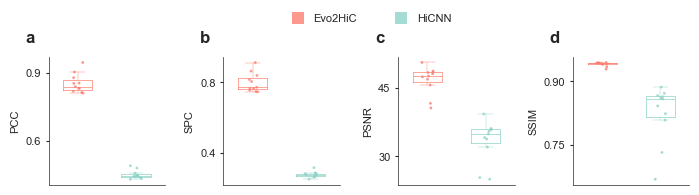

In [15]:
labels = ['a', 'b', 'c', 'd']

for ax, label in zip(axes_top[0], labels):
    ax.text(
        -0.2, 1.2, f'{label}',           # 相对位置：左上角内一点
        transform=ax.transAxes, 
        fontsize=12,
        fontname='Arial',               # 字体
        fontweight='bold',                  # 粗体 (Nature风格)
        ha='left', va='top'                 # 对齐方式
    )
fig

In [16]:
fig.savefig(str(OUT_DIR / 'supplementary_16.pdf'))